# Replicate credit scoring.
using information value (IV), weight of evidence (WoE) for feature selection, logistic regression for scoring model and reverse back to credit score.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/GiveMeSomeCredit/Data Dictionary.xls
/kaggle/input/GiveMeSomeCredit/cs-training.csv
/kaggle/input/GiveMeSomeCredit/sampleEntry.csv
/kaggle/input/GiveMeSomeCredit/cs-test.csv


In [2]:
df_train = pd.read_csv('/kaggle/input/GiveMeSomeCredit/cs-training.csv')
df_test = pd.read_csv('/kaggle/input/GiveMeSomeCredit/cs-test.csv')
df_train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# EDA

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [4]:
null_val_sums = df_train.isnull().sum()

In [5]:
pd.DataFrame({'Column': null_val_sums.index, 'Number of Null Values': null_val_sums.values, 'Proportions': null_val_sums.values/len(df_train)})

,Column,Number of Null Values,Proportions
0,Unnamed: 0,0,0.000000
1,SeriousDlqin2yrs,0,0.000000
2,RevolvingUtilizationOfUnsecuredLines,0,0.000000
3,age,0,0.000000
4,NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
5,DebtRatio,0,0.000000
6,MonthlyIncome,29731,0.198207
7,NumberOfOpenCreditLinesAndLoans,0,0.000000
8,NumberOfTimes90DaysLate,0,0.000000
9,NumberRealEstateLoansOrLines,0,0.000000


In [6]:
df_train = df_train.fillna(df_train.median())
print(df_train.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


Default Rate: 0.06684


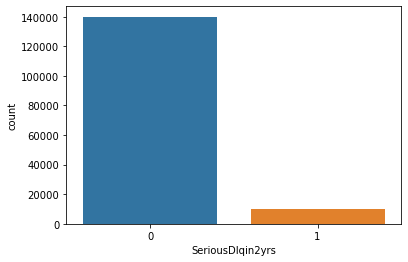

In [7]:
sns.countplot(x='SeriousDlqin2yrs', data=df_train)
print('Default Rate: {}'.format(df_train['SeriousDlqin2yrs'].sum()/len(df_train)))

# Binning

In [8]:
age_bins = [-math.inf, 25, 40, 50, 60, 70, math.inf]
dependent_bin = [-math.inf,2,4,6,8,10,math.inf]
dpd_bins = [-math.inf,1,2,3,4,5,6,7,8,9,math.inf]
df_train['bin_age'] = pd.cut(df_train['age'],bins=age_bins).astype(str)
df_train['bin_NumberOfDependents'] = pd.cut(df_train['NumberOfDependents'],bins=dependent_bin).astype(str)
df_train['bin_NumberOfTimes90DaysLate'] = pd.cut(df_train['NumberOfTimes90DaysLate'],bins=dpd_bins)
df_train['bin_NumberOfTime30-59DaysPastDueNotWorse'] = pd.cut(df_train['NumberOfTime30-59DaysPastDueNotWorse'], bins=dpd_bins)
df_train['bin_NumberOfTime60-89DaysPastDueNotWorse'] = pd.cut(df_train['NumberOfTime60-89DaysPastDueNotWorse'], bins=dpd_bins)


df_train['bin_RevolvingUtilizationOfUnsecuredLines'] = pd.qcut(df_train['RevolvingUtilizationOfUnsecuredLines'],q=5,duplicates='drop').astype(str)
df_train['bin_DebtRatio'] = pd.qcut(df_train['DebtRatio'],q=5,duplicates='drop').astype(str)
df_train['bin_MonthlyIncome'] = pd.qcut(df_train['MonthlyIncome'],q=5,duplicates='drop').astype(str)
df_train['bin_NumberOfOpenCreditLinesAndLoans'] = pd.qcut(df_train['NumberOfOpenCreditLinesAndLoans'],q=5,duplicates='drop').astype(str)
df_train['bin_NumberRealEstateLoansOrLines'] = pd.qcut(df_train['NumberRealEstateLoansOrLines'],q=5,duplicates='drop').astype(str)

In [9]:
bin_cols = [c for c in df_train.columns.values if c.startswith('bin_')]

In [10]:
df_train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,...,bin_age,bin_NumberOfDependents,bin_NumberOfTimes90DaysLate,bin_NumberOfTime30-59DaysPastDueNotWorse,bin_NumberOfTime60-89DaysPastDueNotWorse,bin_RevolvingUtilizationOfUnsecuredLines,bin_DebtRatio,bin_MonthlyIncome,bin_NumberOfOpenCreditLinesAndLoans,bin_NumberRealEstateLoansOrLines
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,...,"(40.0, 50.0]","(-inf, 2.0]","(-inf, 1.0]","(1.0, 2.0]","(-inf, 1.0]","(0.699, 50708.0]","(0.468, 4.0]","(8250.0, 3008750.0]","(12.0, 58.0]","(2.0, 54.0]"
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,...,"(25.0, 40.0]","(-inf, 2.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(0.699, 50708.0]","(-0.001, 0.134]","(-0.001, 3400.0]","(-0.001, 4.0]","(-0.001, 1.0]"
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,...,"(25.0, 40.0]","(-inf, 2.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(0.271, 0.699]","(-0.001, 0.134]","(-0.001, 3400.0]","(-0.001, 4.0]","(-0.001, 1.0]"
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,...,"(25.0, 40.0]","(-inf, 2.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(0.0832, 0.271]","(-0.001, 0.134]","(-0.001, 3400.0]","(4.0, 6.0]","(-0.001, 1.0]"
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,...,"(40.0, 50.0]","(-inf, 2.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(0.699, 50708.0]","(-0.001, 0.134]","(8250.0, 3008750.0]","(6.0, 9.0]","(-0.001, 1.0]"


# Features Extracting
use IV and WoE for extracting

In [11]:
def calculate_IV(df_train, feature, target):
    crstab = pd.crosstab(df_train[feature], df_train[target], normalize = 'columns')
    
    #crstab['Log_a_b'] = np.log(crstab[0]) - np.log(crstab[1])
    crstab['WOE'] =   np.log(crstab[crstab.columns[0]]/crstab[crstab.columns[1]]) 
    crstab = crstab.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    crstab['diff_0_1'] =  crstab[crstab.columns[0]] - crstab[crstab.columns[1]]
    crstab['IV_i'] = crstab['WOE']*crstab['diff_0_1']
    IV = sum(crstab['IV_i'])
    # print(crstab)
    return IV

# recalculate IV 1 4
# f = bin_cols[2]
# calculate_IV(df_train,f,'SeriousDlqin2yrs')

In [12]:
# recalculate IV
IV_list_ = []
for f in bin_cols:
#     IV_list_.append([f,cal_IV(df_train,f,'SeriousDlqin2yrs')])
     IV_list_.append([f,calculate_IV(df_train,f,'SeriousDlqin2yrs')])
IV_data_ = pd.DataFrame(IV_list_, columns=['features','IV'])
print(IV_data_)

                                   features        IV
0                                   bin_age  0.240411
1                    bin_NumberOfDependents  0.014508
2               bin_NumberOfTimes90DaysLate  0.491607
3  bin_NumberOfTime30-59DaysPastDueNotWorse  0.492445
4  bin_NumberOfTime60-89DaysPastDueNotWorse  0.266558
5  bin_RevolvingUtilizationOfUnsecuredLines  1.059619
6                             bin_DebtRatio  0.059488
7                         bin_MonthlyIncome  0.056234
8       bin_NumberOfOpenCreditLinesAndLoans  0.048023
9          bin_NumberRealEstateLoansOrLines  0.012091


In [13]:
# We choose only those features with IV>0.1
feature_cols = ['RevolvingUtilizationOfUnsecuredLines','NumberOfTime30-59DaysPastDueNotWorse','age','NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse']
bin_cols = ['bin_RevolvingUtilizationOfUnsecuredLines','bin_NumberOfTime30-59DaysPastDueNotWorse','bin_age','bin_NumberOfTimes90DaysLate','bin_NumberOfTime60-89DaysPastDueNotWorse']

In [14]:
def cal_WOE(df,features,target):
    df_new = df
    for f in features:
        df_woe = df_new.groupby(f).agg({target:['sum','count']})
        df_woe.columns = list(map(''.join, df_woe.columns.values))
        df_woe = df_woe.reset_index()
        df_woe = df_woe.rename(columns = {target+'sum':'bad'})
        df_woe = df_woe.rename(columns = {target+'count':'all'})
        df_woe['good'] = df_woe['all']-df_woe['bad']
        df_woe = df_woe[[f,'good','bad']]
        df_woe['bad_rate'] = df_woe['bad']/df_woe['bad'].sum()
        df_woe['good_rate'] = df_woe['good']/df_woe['good'].sum()
        df_woe['woe'] = df_woe['bad_rate'].divide(df_woe['good_rate'],fill_value=1)
        df_woe.columns = [c if c==f else c+'_'+f for c in list(df_woe.columns.values)]
        df_new = df_new.merge(df_woe,on=f,how='left')
    return df_new

def WOE(df_train, feature, target):
    crstab = pd.crosstab(df_train[feature], df_train[target], normalize = 'columns')
    crstab_ = pd.crosstab(df_train[feature], df_train[target])
    crstab['woe'] = crstab[crstab.columns[1]].divide(crstab[crstab.columns[0]], fill_value=1) 
    crstab = crstab.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    df_woe = pd.DataFrame(crstab.values, index=crstab.index)
    df_woe.columns = ['good_rate', 'bad_rate', 'woe']
    df_woe.columns = [st + "_" + feature for st in df_woe.columns]
    
    return df_woe

def calculate_WOE(df,features,target):
    df_new = df
    for f in features:
        df_woe = WOE(df_new, f, target)
        df_new = df_new.merge(df_woe, on = f, how='left')
    woe_cols = [c for c in df_new.columns if 'woe' in c]
    # return df_new[woe_cols]
    return df_new # full data frame
#print(bin_cols)
#calculate_WOE(df_train,bin_cols,'SeriousDlqin2yrs')

In [15]:
df_woe = cal_WOE(df_train,bin_cols,'SeriousDlqin2yrs')
df_woe.head()
# woe_cols = [c for c in list(df_woe.columns.values) if 'woe' in c]
# df_woe[woe_cols]

# my calculation
df_woe = calculate_WOE(df_train,bin_cols,'SeriousDlqin2yrs')
woe_cols = [c for c in df_woe.columns if 'woe' in c]
df_woe[woe_cols].head()

,woe_bin_RevolvingUtilizationOfUnsecuredLines,woe_bin_NumberOfTime30-59DaysPastDueNotWorse,woe_bin_age,woe_bin_NumberOfTimes90DaysLate,woe_bin_NumberOfTime60-89DaysPastDueNotWorse
0,3.463412,5.036574,1.256516,0.838053,0.906658
1,3.463412,0.772730,1.599270,0.838053,0.906658
2,1.054603,0.772730,1.599270,0.838053,0.906658
3,0.420420,0.772730,1.599270,0.838053,0.906658
4,3.463412,0.772730,1.256516,0.838053,0.906658


In [16]:
df_bin_to_woe = pd.DataFrame(columns = ['features','bin','woe'])
for f in feature_cols:
    b = 'bin_'+f
    w = 'woe_bin_'+f
    df = df_woe[[w,b]].drop_duplicates()
    df.columns = ['woe','bin']
    df['features'] = f
    df=df[['features','bin','woe']]
    df_bin_to_woe = pd.concat([df_bin_to_woe,df])
df_bin_to_woe.head()

,features,bin,woe
0,RevolvingUtilizationOfUnsecuredLines,"(0.699, 50708.0]",3.463412
2,RevolvingUtilizationOfUnsecuredLines,"(0.271, 0.699]",1.054603
3,RevolvingUtilizationOfUnsecuredLines,"(0.0832, 0.271]",0.420420
11,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.0192]",0.276204
14,RevolvingUtilizationOfUnsecuredLines,"(0.0192, 0.0832]",0.235185


# Modeling and Training

Used logistc regression rather than advanced NN or xgboost model for credit scoring. 

Logistic is intuitively explanable and meets the model requirements under survilence in banks  

In [17]:
# split data 80/20 for training and validating
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(df_woe[woe_cols], df_woe['SeriousDlqin2yrs'], test_size=0.2, random_state=66)
model = LogisticRegression().fit(X_train,y_train)

In [18]:
model.score(X_test,y_test)

0.9376666666666666

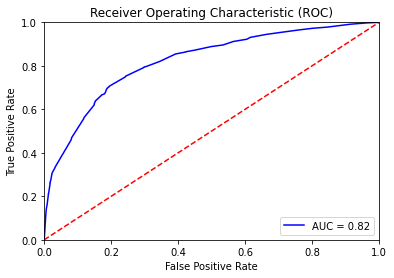

0.5118748830059452


In [19]:
import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
probs = model.predict_proba(X_test)

preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic (ROC)')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# K-S value, max(tpr - fpr) to measure the discrimination of predict model
# >=0.5 is considered good differentiation 
print(max(tpr - fpr))

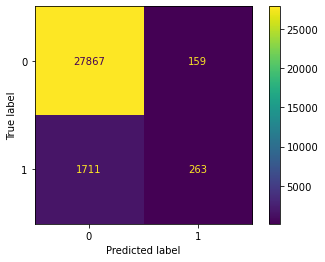

In [20]:
# Confusion matrix
y_pred = model.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(cm).plot()

In [21]:
model.coef_

array([[0.53573258, 0.17183833, 0.56093052, 0.09287986, 0.06693828]])

# Get credit scores
credit score is linear transformation of log odds

In [22]:
theta_0 = 1/1
P_0 = 650 # base score
PDO = 50 # point of double

In [23]:
B = PDO/np.log(2)
A = P_0+B*np.log(theta_0)

In [24]:
def generate_scorecard(model_coef,binning_df,features,B):
    lst = []
    cols = ['Variable','Binning','Score']
    coef = model_coef[0]
    for i in range(len(features)):
        f = features[i]
        df = binning_df[binning_df['features']==f]
        for index,row in df.iterrows():
            lst.append([f,row['bin'],int(round(-coef[i]*row['woe']*B))])
    data = pd.DataFrame(lst, columns=cols)
    return data

In [25]:
score_card = generate_scorecard(model.coef_,df_bin_to_woe,feature_cols,B)
score_card.head()

,Variable,Binning,Score
0,RevolvingUtilizationOfUnsecuredLines,"(0.699, 50708.0]",-134
1,RevolvingUtilizationOfUnsecuredLines,"(0.271, 0.699]",-41
2,RevolvingUtilizationOfUnsecuredLines,"(0.0832, 0.271]",-16
3,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.0192]",-11
4,RevolvingUtilizationOfUnsecuredLines,"(0.0192, 0.0832]",-9


In [26]:
sort_scorecard = score_card.groupby('Variable').apply(lambda x: x.sort_values('Score', ascending=False))
sort_scorecard.head()

Variable  \
Variable                                                                        
NumberOfTime30-59DaysPastDueNotWorse 6   NumberOfTime30-59DaysPastDueNotWorse   
                                     5   NumberOfTime30-59DaysPastDueNotWorse   
                                     13  NumberOfTime30-59DaysPastDueNotWorse   
                                     14  NumberOfTime30-59DaysPastDueNotWorse   
                                     7   NumberOfTime30-59DaysPastDueNotWorse   

                                             Binning  Score  
Variable                                                     
NumberOfTime30-59DaysPastDueNotWorse 6   (-inf, 1.0]    -10  
                                     5    (1.0, 2.0]    -62  
                                     13   (7.0, 8.0]    -81  
                                     14   (8.0, 9.0]    -87  
                                     7    (2.0, 3.0]    -94

In [27]:
def str_to_int(s):
    if s == '-inf':
        return -999999999.0
    elif s=='inf':
        return 999999999.0
    else:
        return float(s)
    
def map_value_to_bin(feature_value,feature_to_bin):
    for idx, row in feature_to_bin.iterrows():
        bins = str(row['Binning'])
        left_open = bins[0]=="("
        right_open = bins[-1]==")"
        binnings = bins[1:-1].split(',')
        in_range = True
        # check left bound
        if left_open:
            if feature_value<= str_to_int(binnings[0]):
                in_range = False   
        else:
            if feature_value< str_to_int(binnings[0]):
                in_range = False   
        #check right bound
        if right_open:
            if feature_value>= str_to_int(binnings[1]):
                in_range = False 
        else:
            if feature_value> str_to_int(binnings[1]):
                in_range = False   
        if in_range:
            return row['Binning']
    return null

def map_to_score(df,score_card):
    scored_columns = list(score_card['Variable'].unique())
    score = 0
    for col in scored_columns:
        feature_to_bin = score_card[score_card['Variable']==col]
        feature_value = df[col]
        selected_bin = map_value_to_bin(feature_value,feature_to_bin)
        selected_record_in_scorecard = feature_to_bin[feature_to_bin['Binning'] == selected_bin]
        score += selected_record_in_scorecard['Score'].iloc[0]
    return score  

def calculate_score_with_card(df,score_card,A):
    df['score'] = df.apply(map_to_score,args=(score_card,),axis=1)
    df['score'] = df['score']+A
    df['score'] = df['score'].astype(int)
    return df

# Validate score
Sample candiate from training data

In [28]:
good_sample = df_train[df_train['SeriousDlqin2yrs']==0].sample(1000)
good_sample = good_sample[feature_cols]
bad_sample = df_train[df_train['SeriousDlqin2yrs']==1].sample(1000)
bad_sample = bad_sample[feature_cols]

good_candidate = calculate_score_with_card(good_sample,score_card,A)
bad_candidate = calculate_score_with_card(bad_sample,score_card,A)
res = pd.concat([good_candidate, bad_candidate])
res.head()

,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,age,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,score
82338,0.000112,0,36,0,0,554
19336,0.464101,0,30,0,0,524
34727,0.017938,0,49,0,0,568
15675,0.010360,0,65,0,0,599
102578,0.079576,0,55,0,0,584


# Approve card critera
### >= 650   Approved
### 450-650  Pending
### <450     Declined

In [29]:
def approve_or_not(score):
    if score < 450:
        return "Declined"
    elif score >= 450 and score < 650:
        return "Pending"
    else:
        return "Approved"

Pending     1363
Declined     637
Name: Status, dtype: int64


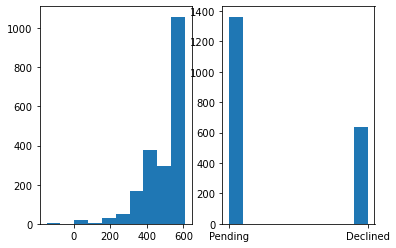

In [30]:
res['Status'] = res['score'].apply(approve_or_not)
print(res['Status'].value_counts())
fig, axs = plt.subplots(1,2)
axs[0].hist(res['score']) 
axs[1].hist(res['Status']) 
fig.show()

1000 good and bad candidates are selected each, 1335 were pending.

In [31]:
pd.crosstab(df_train['SeriousDlqin2yrs'], res['Status'])

Status,Declined,Pending
SeriousDlqin2yrs,,
0,105,895
1,532,468
